### **Multiple Linear Regression Model Testing**

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
sns.set(style='whitegrid')

#### **Generate Random Synthetic Data:**

In [79]:
### random synthetic data
rg = np.random.default_rng(seed=33)

### independent variables; (mean, std., size)
X1 = rg.normal(5, 1, 1000)
X2 = rg.normal(14, 6, 1000)
X3 = rg.normal(20, 9, 1000)
X4 = rg.normal(50, 13, 1000)
noise = rg.normal(0, 7, 1000)

### coefficients
b_0 = 3.100
b_1 = 0.813
b_2 = 3.000
b_3 = 0.287
b_4 = 4.583

### assemble output/dependent variable
y = b_0 + b_1*X1 + b_2*X2 + b_3*X3 + b_4*X4 + noise

df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4,
    'y': y
})
df.head()

,X1,X2,X3,X4,y
0,5.398370,11.598606,12.413956,55.503354,293.338199
1,4.437177,15.408340,27.443034,44.069240,251.207029
2,5.588835,9.214570,21.578595,38.563796,216.889848
3,5.042118,-0.088195,9.920221,56.077871,269.606592
4,3.429099,17.990901,19.169442,46.289283,271.637411


#### **Visualize:**

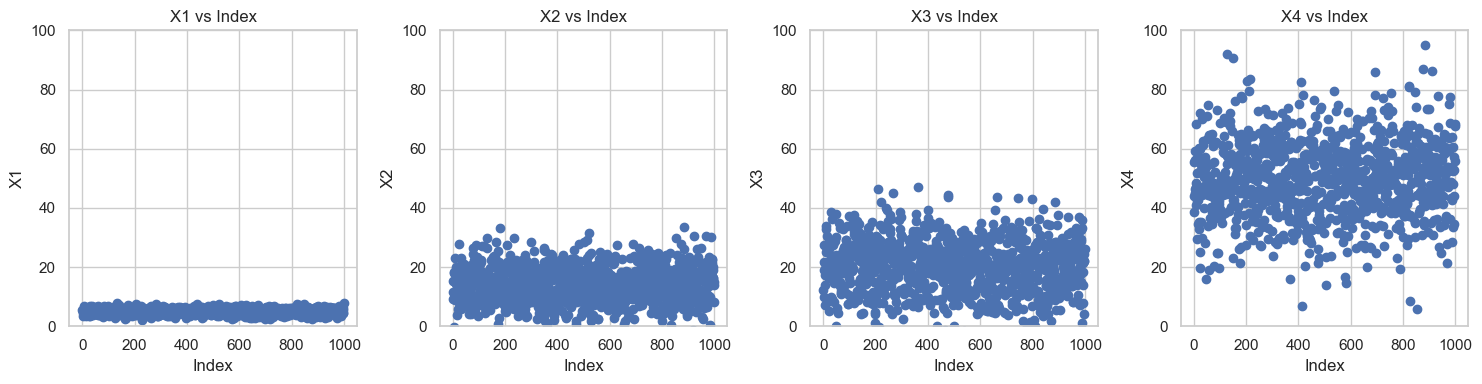

In [80]:
### plot of each x variable
fig, ax = plt.subplots(1, 4, figsize=(15, 4), sharex=True)

ax[0].scatter(df.index, df['X1'])
ax[0].set_title('X1 vs Index')
ax[0].set_xlabel('Index')
ax[0].set_ylabel('X1')
ax[0].set_ylim(0, 100)

ax[1].scatter(df.index, df['X2'])
ax[1].set_title('X2 vs Index')
ax[1].set_xlabel('Index')
ax[1].set_ylabel('X2')
ax[1].set_ylim(0, 100)

ax[2].scatter(df.index, df['X3'])
ax[2].set_title('X3 vs Index')
ax[2].set_xlabel('Index')
ax[2].set_ylabel('X3')
ax[2].set_ylim(0, 100)

ax[3].scatter(df.index, df['X4'])
ax[3].set_title('X4 vs Index')
ax[3].set_xlabel('Index')
ax[3].set_ylabel('X4')
ax[3].set_ylim(0, 100)

plt.tight_layout()
plt.show()

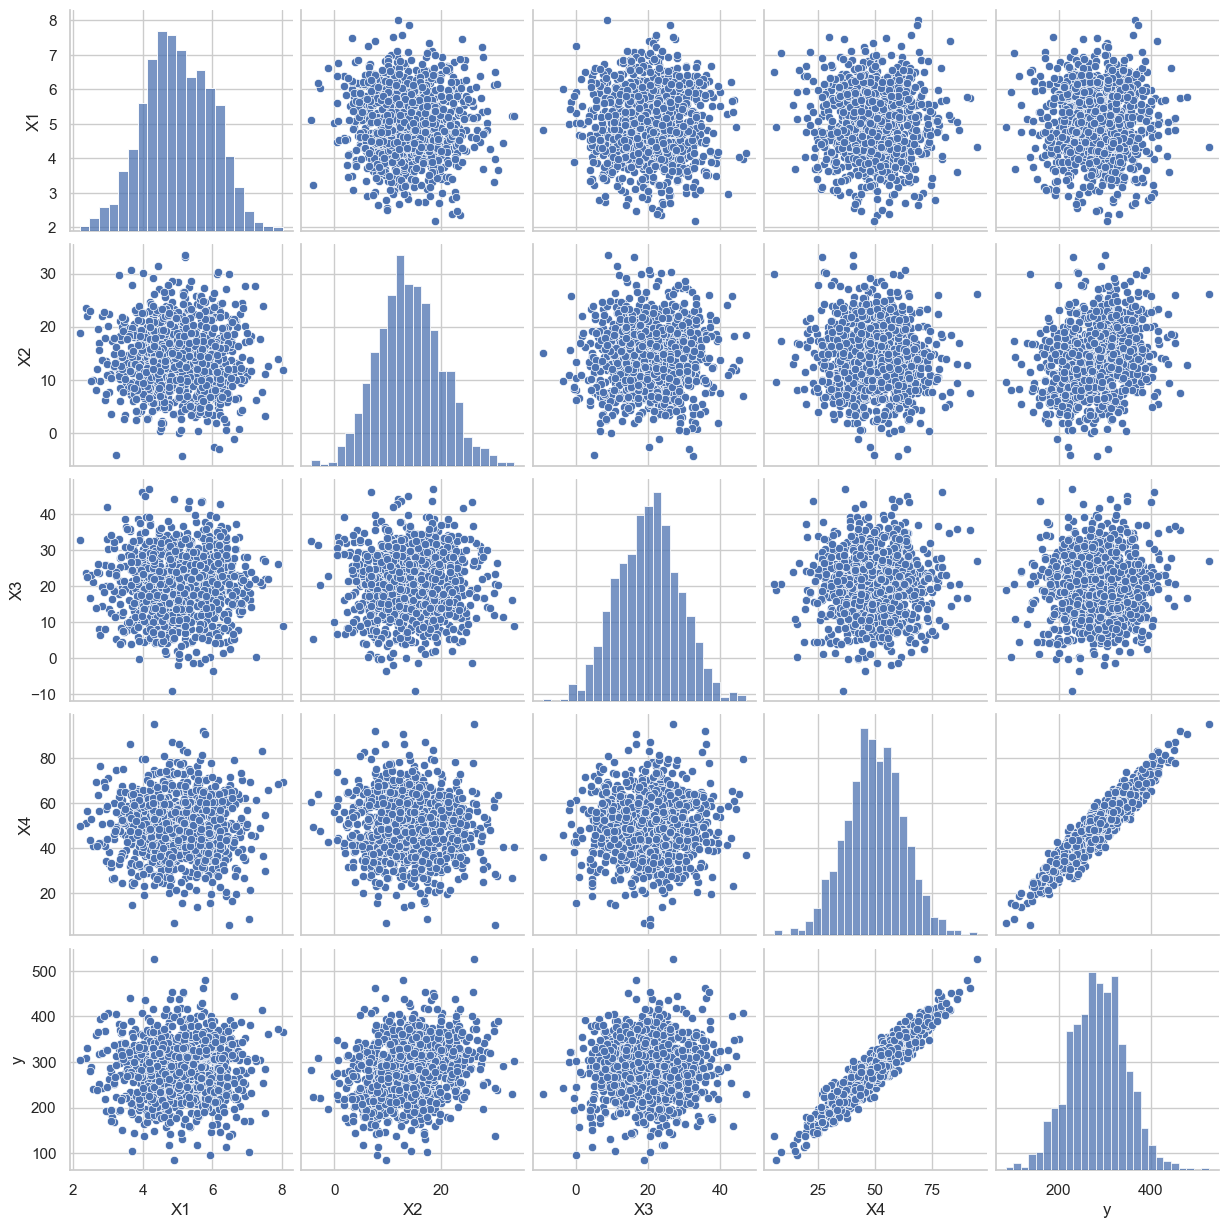

In [81]:
sns.pairplot(df[['X1', 'X2', 'X3', 'X4', 'y']])

#### **Fit Multiple Linear Regression Model:**

In [82]:
### model using sklearn
X = df[['X1', 'X2', 'X3', 'X4']]
y = df['y']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

### metrics
print('Intercept:', model.intercept_)
print('Actual Intercept:', b_0)

print('\nCoefficients:', model.coef_)
print('Actual Coefficients:', b_1, b_2, b_3, b_4)

print('\nR^2 Score:', r2_score(y, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y, y_pred)))

Intercept: 4.486996778009484
Actual Intercept: 3.1

Coefficients: [0.80756968 3.05616837 0.2508199  4.56333612]
Actual Coefficients: 0.813 3.0 0.287 4.583

R^2 Score: 0.9877720706629278
RMSE: 6.833808009480207


### **Assumptions Testing:**

#### 1. Linearity:
* We cannot simply plot y vs. x to confirm linearity, since we have multiple x variables X1, X2, X3, etc; instead plot the residuals vs. the fitted values, which shows residuals on the y-axis and fitted (predicted) values on the x-axis.
  - A random scatter around zero suggests linearity
  - Systematic patterns (curves) suggest non-linearity

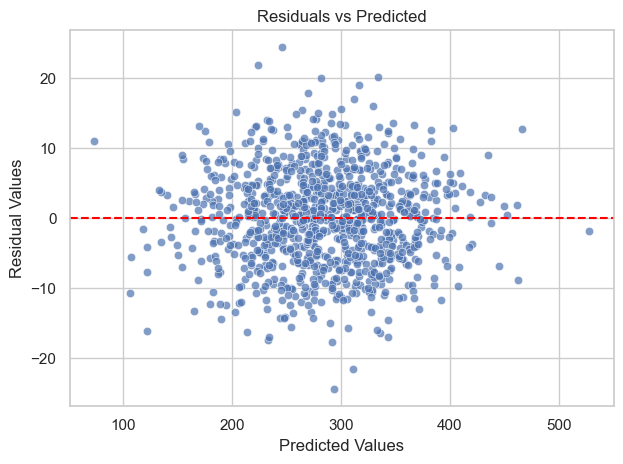

In [83]:
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residual Values')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

#### 2. Independence
* A plot of the residuals over time should show no pattern emerging.
* The Durbin-Watson test can be used to find autocorrelation between residuals. If they are correlated, the standard errors of the coefficients can be underestimated, resulting in misleading inferences:
  - (0 - 1) = strong positive autocorrelation
  - ( < 2 ) = positive autocorrelation
  - ( 2 ) = no autocorrelation
  - ( > 2 ) = negative autocorrelation
  - (3 - 4) = strong negative autocorrelation

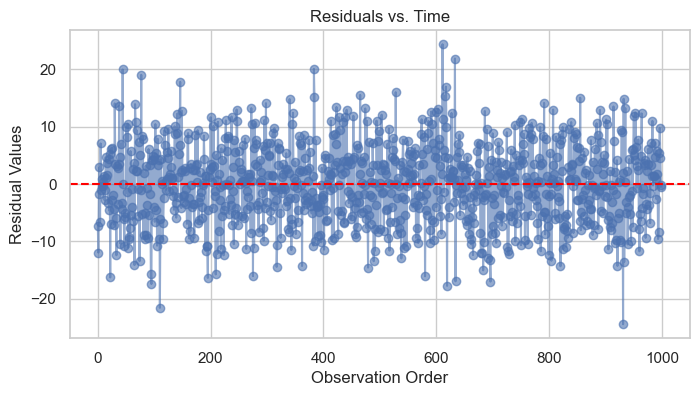

In [84]:
### plot residuals over time
plt.figure(figsize=(8, 4))
plt.plot(residuals, marker='o', alpha=0.6)
plt.title('Residuals vs. Time')
plt.xlabel('Observation Order')
plt.ylabel('Residual Values')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [85]:
### Durbin-Watson Test
dw_stat = durbin_watson(residuals)
print('Durbin-Watson Statistic:', dw_stat)

Durbin-Watson Statistic: 2.015649976019468


#### 3. Homoscedasticity:
* Homoscedasticity means a constant variance of residuals across all levels of the independent variable.
* A random scattering around zero suggests linearity

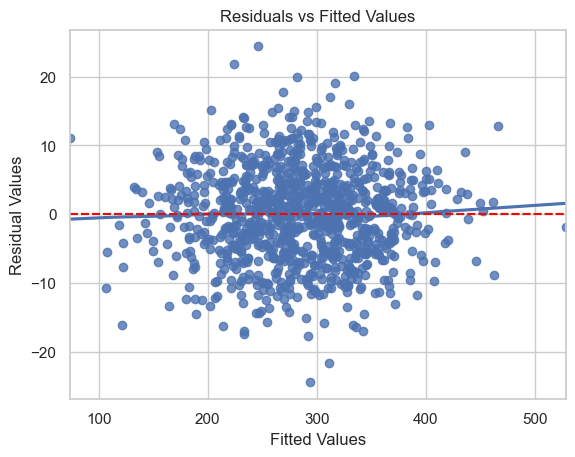

In [86]:
sns.residplot(x=y_pred, y=residuals, lowess=True)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Fitted Values')
plt.ylabel('Residual Values')
plt.title('Residuals vs Fitted Values')
plt.show()

#### 4. Normality of Residuals:
* A simple histogram quickly shows the shape of the distribution
* A Quantile-Quantile Plot: quantiles of your data on y-axis, quanitiles of a theoretical distribution on x-axis
  - points lie on line = data follows distribution
  - points curve up or down = skewness (right or left)
  - points deviate at ends = heavy or light tailed distributions
  - individual points far off of line = outliers
* The Shapiro-Wilk Test; recommended for n<=50 but is usable up to approximately 2000 observations
  - if p-value is less than your chosen significance level = data is likely not normal
  - if p-value is high = suggest the data may be normal

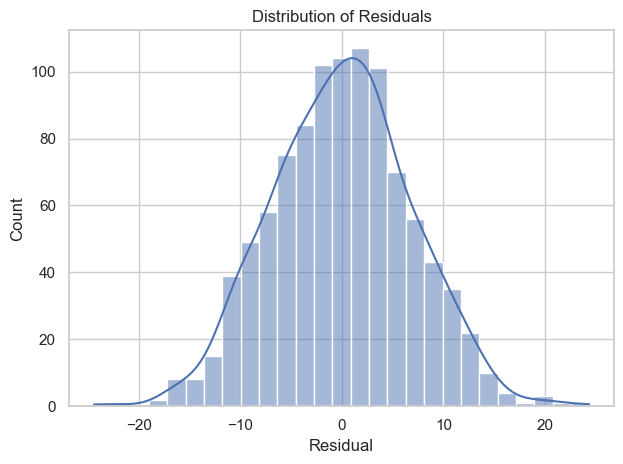

In [87]:
### Normality of Residuals
plt.figure()
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

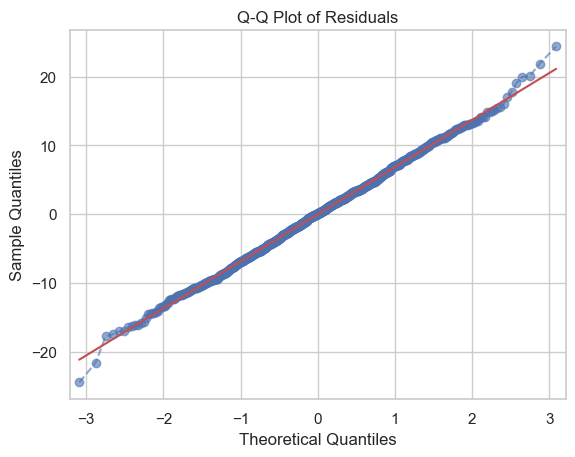

In [88]:
### statsmodels Q-Q Plot
fig = sm.qqplot(residuals, line='s', linestyle='--', alpha=0.6)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [89]:
### The Shapiro-Wilk Test
stat, p = shapiro(residuals)
print(f'Shapiro-Wilk Test:\nStatistic = {stat:.3f}\nP-value = {p:.3f}')

Shapiro-Wilk Test:
Statistic = 0.999
P-value = 0.907


#### 5. Multicolinearity:
* If two or more predictor variables are highly linearly correlated, one predictor can be linearly predicted from the others with a substantial degree of accuracy.
* Multicolinearity undermines the statistical significance of independent variables; it becomes hard to determine the individual effect or correlated predictors

##### Pearson Correlation Coefficient (PCC)
* Measures strength and direction of the linear relationship between two variables.
  - +1 = perfect positive linear correlation
  - 0 = no linear correlation
  - -1 = perfect negative linear correlation

##### Variance Inflation Factor (VIF)
* quantifies how much the variance of a regression coefficient is inflated due to multicolinearity with other predictors.
  - 1 = no correlation between x_j and other variables
  - (> 1) = some correlation exists
  - (> 5) = potential multicolinearity (5 is the warning threshold)
  - (> 10) = strong multicolinearity; consider removing or combining predictors

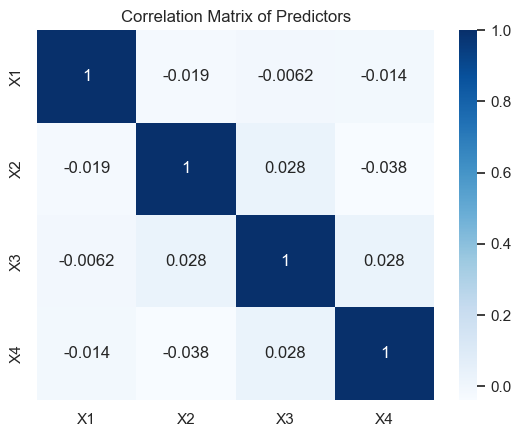

In [90]:
### correlation matrix heat map
sns.heatmap(df[['X1', 'X2', 'X3', 'X4']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix of Predictors')
plt.show()

In [91]:
### Variance Inflation Factor (VIF) Calculation 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# best practice to include the intercept factor in the VIF calculation to make sure the VIF calculation does not misrepresent the influence of correlated variables
X_with_const = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df['Feature'] = X_with_const.columns
vif_df['VIF'] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
vif_df = vif_df[vif_df['Feature'] != 'const']

vif_df

,Feature,VIF
1,X1,1.000600
2,X2,1.002713
3,X3,1.001684
4,X4,1.002530
